# Tulya Semantic Frontier v2

This notebook runs the strengthened semantic-frontier benchmark. The implementation lives in `semantic_frontier_v2.py` in the same GitHub repository so the experiment code can be versioned and tested independently.

Version 2 adds joint exact accuracy, `H(S|Z)`, `H(Z|S)`, `I(S;Z)`, exact partition equivalence, per-future-task uncertainty, recoverable task identities, and probability-weighted future semantic uncertainty.

**Recommended first rerun:** keep both switches below `False`. After sharing the new outputs, we can decide whether to enable the larger sweep or long grokking run.

In [9]:
RUN_SWEEP = False
RUN_LONG = False

print('RUN_SWEEP =', RUN_SWEEP)
print('RUN_LONG  =', RUN_LONG)

RUN_SWEEP = False
RUN_LONG  = False


## Load the experiment module from GitHub

The repository is public, so the notebook downloads the exact `main` version of the module. If you imported/cloned the whole repository into the Kaggle working directory, the local file is used instead.

In [10]:
from pathlib import Path
import importlib.util, requests, sys

local_candidates = [
    Path('/kaggle/working/semantic_frontier_v2.py'),
    Path('semantic_frontier_v2.py'),
]
module_path = next((p for p in local_candidates if p.exists()), None)

if module_path is None:
    module_path = Path('/kaggle/working/semantic_frontier_v2.py')
    url = 'https://raw.githubusercontent.com/Vedsaga/tulya-training-dynamics/main/semantic_frontier_v2.py'
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    module_path.write_bytes(r.content)
    print('Downloaded', url)
else:
    print('Using local module:', module_path)

spec = importlib.util.spec_from_file_location('semantic_frontier_v2', module_path)
sf = importlib.util.module_from_spec(spec)
sys.modules['semantic_frontier_v2'] = sf
spec.loader.exec_module(sf)
print('Loaded semantic_frontier_v2 from', module_path)

Downloaded https://raw.githubusercontent.com/Vedsaga/tulya-training-dynamics/main/semantic_frontier_v2.py
Loaded semantic_frontier_v2 from /kaggle/working/semantic_frontier_v2.py


## Run

A default run writes the strengthened demo outputs. The sweep and long grokking experiment are opt-in.

torch 2.10.0+cu128 device cuda
GPU Tesla T4

Exact frontier
 task_count                                                                        tasks  classes  entropy_bits  fixed_bits  raw_bits
          1                                                                        bit_0        2      1.000000           1        12
          2                                                                  bit_0,bit_1        4      2.000000           2        12
          3                                                          bit_0,bit_1,xor_2_3        8      3.000000           3        12
          4                                                 bit_0,bit_1,xor_2_3,majority       16      3.881009           4        12
          5                               bit_0,bit_1,xor_2_3,majority,first_half_parity       32      4.879368           5        12
          6            bit_0,bit_1,xor_2_3,majority,first_half_parity,popcount_mod3_zero       63      5.697093           6        12
  

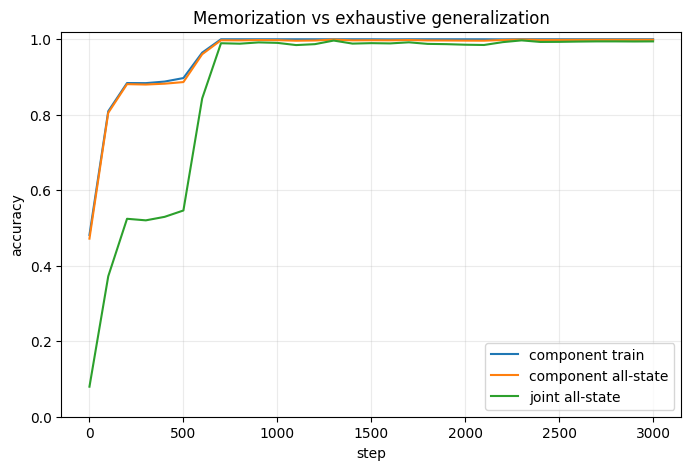

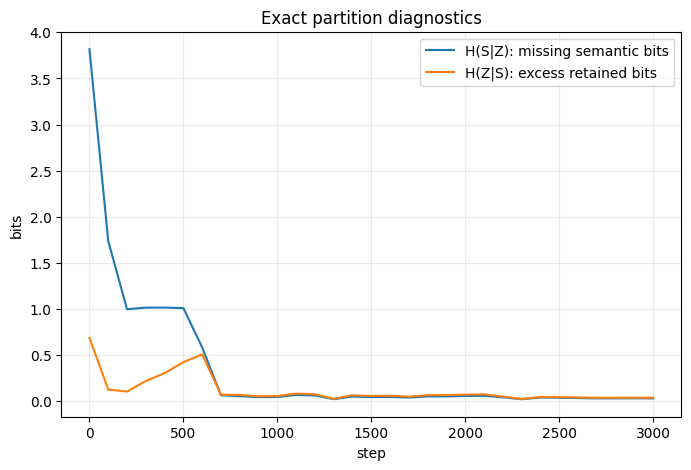

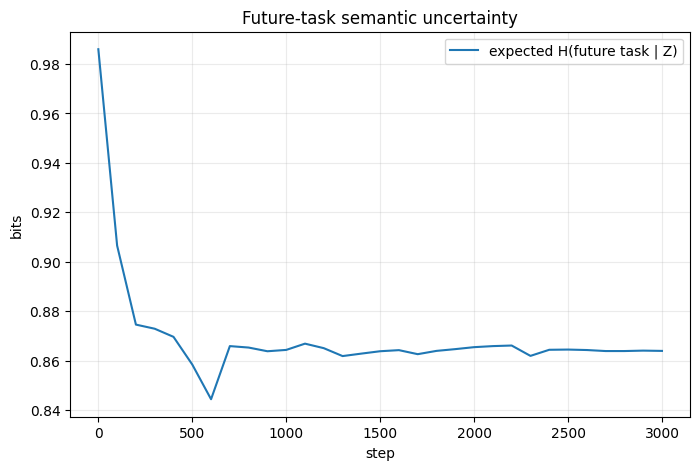


Saved: ['benchmark_metadata.json', 'demo_future_task_trace.csv', 'demo_summary.json', 'demo_trace.csv', 'exact_frontier.csv', 'task_surprise_vs_semantic_novelty.csv']


{'tasks': ['bit_0', 'bit_1', 'xor_2_3', 'majority'],
 'bottleneck_bits': 4,
 'n_train_states': 1024,
 'steps': 3000,
 'theoretical_classes': 16,
 'theoretical_entropy_bits': 3.881008923584874,
 'theoretical_fixed_bits': 4,
 'learned_classes': 16,
 'learned_code_entropy_bits': 3.8875357995010473,
 'h_semantic_given_code': 0.03029698240453138,
 'h_code_given_semantic': 0.03682385832070478,
 'mutual_information_semantic_code': 3.8507119411803425,
 'semantic_sufficient': False,
 'partition_equivalent': False,
 'final_train_acc': 1.0,
 'final_all_state_acc': 0.99859619140625,
 'final_joint_train_accuracy': 1.0,
 'final_joint_all_state_accuracy': 0.994384765625,
 'future_recoverable_tasks': ['xor_0_1'],
 'expected_future_semantic_uncertainty_bits': 0.8639958861433095,
 'prior_weighted_future_unresolved_bits': 0.3926897337951987,
 'future_task_probability_mass': 0.4545041707872947}

In [11]:
summary = sf.run_all(run_sweep=RUN_SWEEP, run_long=RUN_LONG)
summary

## Files to share after the default rerun

Please share these six files from `/kaggle/working/tulya_semantic_frontier/`:

- `benchmark_metadata.json`
- `demo_summary.json`
- `demo_trace.csv`
- `demo_future_task_trace.csv`
- `exact_frontier.csv`
- `task_surprise_vs_semantic_novelty.csv`

If you later enable `RUN_SWEEP`, also share `n_bits_compute_sweep.csv`. If you enable `RUN_LONG`, share the grokking trace and summary too.